## 1. Import Required Libraries

In [145]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Configure Output Directory

In [146]:
# Create output directory for charts
os.makedirs('visualizations', exist_ok=True)
print("✓ Output directory ready: ./visualizations/")

✓ Output directory ready: ./visualizations/


## 3. Load and Discover CSV Files

In [147]:
# Get all CSV files in the directory (exclude combined file)
# Path to the folder containing CSV files
folder_path = "./Weeks3&4Exercise"

# Get all CSV files in the folder
csv_files = glob.glob("**/*.csv")
csv_files = [f for f in csv_files if 'Combined' not in f]
csv_files.sort()

import os  # Added import for os module

print(f"Found {len(csv_files)} CSV files:")
for file in csv_files:
    # Extract just the filename without the path
    filename = os.path.basename(file)
    print(f"  - {filename}")

Found 25 CSV files:
  - 2021_WAVES-ACCESS-RECORDS.csv
  - 2022-01_WAVES-ACCESS-RECORDS.csv
  - 2022-02_WAVES-ACCESS-RECORDS.csv
  - 2022-03_WAVES-ACCESS-RECORDS.csv
  - 2022-04_WAVES-ACCESS-RECORDS.csv
  - 2022-05_WAVES-ACCESS-RECORDS.csv
  - 2022-06_WAVES-ACCESS-RECORDS.csv
  - 2022-07_WAVES-ACCESS-RECORDS.csv
  - 2022-08_WAVES-ACCESS-RECORDS.csv
  - 2022-09_WAVES-ACCESS-RECORDS.csv
  - 2022-10_WAVES-ACCESS-RECORDS.csv
  - 2022-11_WAVES-ACCESS-RECORDS.csv
  - 2022-12_WAVES-ACCESS-RECORDS.csv
  - 2023-01_WAVES-ACCESS-RECORDS.csv
  - 2023-02_WAVES-ACCESS-RECORDS.csv
  - 2023-03_WAVES-ACCESS-RECORDS.csv
  - 2023-04_WAVES-ACCESS-RECORDS.csv
  - 2023-05_WAVES-ACCESS-RECORDS.csv
  - 2023-06_WAVES-ACCESS-RECORDS.csv
  - 2023-07_WAVES-ACCESS-RECORDS.csv
  - 2023-08_WAVES-ACCESS-RECORDS.csv
  - 2023-09_WAVES-ACCESS-RECORDS.csv
  - 2023-10_WAVES-ACCESS-RECORDS.csv
  - 2023-11_WAVES-ACCESS-RECORDS.csv
  - 2023-12_WAVES-ACCESS-RECORDS.csv


    ll## 4. Combine All CSV Files

In [148]:
# Read and combine all CSV files
dataframes = []
for file in csv_files:
    try:
        df = pd.read_csv(file, encoding='utf-8', low_memory=False)
        df['source_file'] = os.path.basename(file)  # Track which file each record came from
        dataframes.append(df)
        print(f"Loaded {os.path.basename(file)}: {len(df):,} records")
    except Exception as e:
        print(f"Error loading {file}: {e}")

# Combine all dataframes
combined_df = pd.concat(dataframes, ignore_index=True)

print(f"\n{'='*60}")
print(f"Combined dataset: {len(combined_df):,} total records")
print(f"{'='*60}")

Loaded 2021_WAVES-ACCESS-RECORDS.csv: 41,412 records
Loaded 2022-01_WAVES-ACCESS-RECORDS.csv: 1,185 records
Loaded 2022-02_WAVES-ACCESS-RECORDS.csv: 2,155 records
Loaded 2022-03_WAVES-ACCESS-RECORDS.csv: 6,065 records
Loaded 2022-04_WAVES-ACCESS-RECORDS.csv: 13,524 records
Loaded 2022-05_WAVES-ACCESS-RECORDS.csv: 20,105 records
Loaded 2022-06_WAVES-ACCESS-RECORDS.csv: 17,400 records
Loaded 2022-07_WAVES-ACCESS-RECORDS.csv: 39,780 records
Loaded 2022-08_WAVES-ACCESS-RECORDS.csv: 31,055 records
Loaded 2022-09_WAVES-ACCESS-RECORDS.csv: 37,269 records
Loaded 2022-10_WAVES-ACCESS-RECORDS.csv: 39,293 records
Loaded 2022-11_WAVES-ACCESS-RECORDS.csv: 27,938 records
Loaded 2022-12_WAVES-ACCESS-RECORDS.csv: 87,061 records
Loaded 2023-01_WAVES-ACCESS-RECORDS.csv: 34,734 records
Loaded 2023-02_WAVES-ACCESS-RECORDS.csv: 45,610 records
Loaded 2023-03_WAVES-ACCESS-RECORDS.csv: 69,770 records
Loaded 2023-04_WAVES-ACCESS-RECORDS.csv: 69,858 records
Loaded 2023-05_WAVES-ACCESS-RECORDS.csv: 83,402 record

## 5. Save Combined Dataset

In [149]:
# Save combined data
combined_df.to_csv('WAVES_Combined_2021-2023.csv', index=False)
print(f"✓ Combined dataset saved: WAVES_Combined_2021-2023.csv")
print(f"   Total records: {len(combined_df):,}")
print(f"   File size: {os.path.getsize('WAVES_Combined_2021-2023.csv') / (1024*1024):.2f} MB")

✓ Combined dataset saved: WAVES_Combined_2021-2023.csv
   Total records: 1,207,458
   File size: 270.60 MB


## 6. Dataset Overview and Statistics

In [150]:
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Total Records: {len(combined_df):,}")
print(f"Date Range: 2021-2023")
print(f"Number of Files Combined: {len(csv_files)}")
print(f"\nColumns ({len(combined_df.columns)}):")
for i, col in enumerate(combined_df.columns, 1):
    print(f"  {i:2d}. {col}")


DATASET OVERVIEW
Total Records: 1,207,458
Date Range: 2021-2023
Number of Files Combined: 25

Columns (50):
   1. NAMELAST
   2. NAMEFIRST
   3. NAMEMID
   4. UIN
   5. BDGNBR
   6. ACCESS_TYPE
   7. TOA
   8. POA
   9. TOD
  10. POD
  11. APPT_MADE_DATE
  12. APPT_START_DATE
  13. APPT_END_DATE
  14. APPT_CANCEL_DATE
  15. TOTAL_PEOPLE
  16. LAST_UPDATEDBY
  17. POST
  18. LASTENTRYDATE
  19. TERMINAL_SUFFIX
  20. VISITEE_NAMELAST
  21. VISITEE_NAMEFIRST
  22. MEETING_LOC
  23. MEETING_ROOM
  24. CALLER_NAME_LAST
  25. CALLER_NAME_FIRST
  26. CALLER_ROOM
  27. RELEASEDATE
  28. source_file
  29. Unnamed: 27
  30. Unnamed: 28
  31. Last Name
  32. First Name
  33. Middle Initial
  34. Access Type
  35. Appointment Made Date
  36. Appointment Start Date
  37. Appointment End Date
  38. Appointment Cancel Date
  39. Total People
  40. Last Updated By
  41. Last Entry Date
  42. Terminal Suffix
  43. Visitee Last Name
  44. Visitee First Name
  45. Meeting Location
  46. Meeting Room
  4

In [151]:
# Missing values analysis
print("\nMissing Values per Column:")
missing_data = combined_df.isnull().sum()
missing_pct = (missing_data / len(combined_df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False).head(20)
print(missing_summary.to_string())


Missing Values per Column:
                         Missing Count  Missing %
CALLER_ROOM                    1207458     100.00
Caller Room                    1207458     100.00
Appointment Cancel Date        1207083      99.97
Unnamed: 28                    1207080      99.97
Unnamed: 27                    1207077      99.97
APPT_CANCEL_DATE               1207018      99.96
TOD                            1194638      98.94
POA                            1186542      98.27
VISITEE_NAMELAST               1136845      94.15
VISITEE_NAMEFIRST              1123381      93.04
LASTENTRYDATE                  1123012      93.01
CALLER_NAME_FIRST              1123012      93.01
CALLER_NAME_LAST               1123012      93.01
MEETING_ROOM                   1123013      93.01
MEETING_LOC                    1123012      93.01
NAMEFIRST                      1123012      93.01
TERMINAL_SUFFIX                1123046      93.01
NAMELAST                       1123013      93.01
ACCESS_TYPE           

In [152]:
# Key statistics
print("\n" + "="*60)
print("KEY STATISTICS")
print("="*60)
print(f"Unique Visitors (by UIN): {combined_df['UIN'].nunique():,}")
print(f"\nAccess Types:")
print(combined_df['Access Type'].value_counts())
print(f"\nTop 10 Meeting Locations:")
print(combined_df['Meeting Location'].value_counts().head(10))
print(f"\nTop 10 Visitees:")
print(combined_df['Visitee Last Name'].value_counts().head(10))


KEY STATISTICS
Unique Visitors (by UIN): 99,895

Access Types:
Access Type
VA    1123012
Name: count, dtype: int64

Top 10 Meeting Locations:
Meeting Location
WH      929446
OEOB    162538
VPR      19908
NEOB     11120
Name: count, dtype: int64

Top 10 Visitees:
Visitee Last Name
Office        676351
POTUS          83267
Teleky         18175
VPOTUS         11497
Mills          10719
Trocola         6607
Hecmanczuk      6049
Juarez          5617
Ballen          4914
Via             4880
Name: count, dtype: int64


## 7. Data Preparation for Time-Based Analysis

Extract dates from filenames and prepare time series data.

In [153]:
# Extract year-month from source file names
def extract_date_from_filename(filename):
    """Extract date from filename like '2023.01_WAVES-ACCESS-RECORDS.csv'"""
    try:
        if '2021' in filename:
            return '2021-01'
        else:
            date_part = filename.split('_')[0]
        
        # Handle different formats: 2023.01 or 2022.05 (with dot)
        if '-' in date_part and date_part.count('-') == 1:
            parts = date_part.split('-')
            if len(parts) == 2 and len(parts[0]) == 4:
                year = parts[0]
                month = parts[1].zfill(2)
                return f"{year}-{month}"
    except:
        return None
    return None
# Apply date extraction
combined_df['year_month'] = combined_df['source_file'].apply(extract_date_from_filename)

# Convert to datetime for better plotting
combined_df['period'] = pd.to_datetime(combined_df['year_month'], format='%Y-%m', errors='coerce')

# Display sample
print("Extracted dates sample:")
print(combined_df[['source_file', 'year_month']].drop_duplicates().head(25))

Extracted dates sample:
                              source_file year_month
0           2021_WAVES-ACCESS-RECORDS.csv    2021-01
41412    2022-01_WAVES-ACCESS-RECORDS.csv    2022-01
42597    2022-02_WAVES-ACCESS-RECORDS.csv    2022-02
44752    2022-03_WAVES-ACCESS-RECORDS.csv    2022-03
50817    2022-04_WAVES-ACCESS-RECORDS.csv    2022-04
64341    2022-05_WAVES-ACCESS-RECORDS.csv    2022-05
84446    2022-06_WAVES-ACCESS-RECORDS.csv    2022-06
101846   2022-07_WAVES-ACCESS-RECORDS.csv    2022-07
141626   2022-08_WAVES-ACCESS-RECORDS.csv    2022-08
172681   2022-09_WAVES-ACCESS-RECORDS.csv    2022-09
209950   2022-10_WAVES-ACCESS-RECORDS.csv    2022-10
249243   2022-11_WAVES-ACCESS-RECORDS.csv    2022-11
277181   2022-12_WAVES-ACCESS-RECORDS.csv    2022-12
364242   2023-01_WAVES-ACCESS-RECORDS.csv    2023-01
398976   2023-02_WAVES-ACCESS-RECORDS.csv    2023-02
444586   2023-03_WAVES-ACCESS-RECORDS.csv    2023-03
514356   2023-04_WAVES-ACCESS-RECORDS.csv    2023-04
584214   2023-05_WAVES

In [154]:
# Create aggregated data for time series
monthly_visits = combined_df.groupby('year_month').size().reset_index(name='total_visits')
monthly_visits['period'] = pd.to_datetime(monthly_visits['year_month'], format='%Y-%m', errors='coerce')
monthly_visits = monthly_visits.dropna(subset=['period'])
monthly_visits = monthly_visits.sort_values('period')

print(f"\n✓ Time series data prepared: {len(monthly_visits)} months")
print(monthly_visits.head())


✓ Time series data prepared: 25 months
  year_month  total_visits     period
0    2021-01         41412 2021-01-01
1    2022-01          1185 2022-01-01
2    2022-02          2155 2022-02-01
3    2022-03          6065 2022-03-01
4    2022-04         13524 2022-04-01


---

# VISUALIZATIONS

The following cells create 11 different types of charts to analyze the White House visitor data.

## Chart 1: Bar Chart - Top Meeting Locations

Creating Stacked Bar Chart: Locations Over Time...


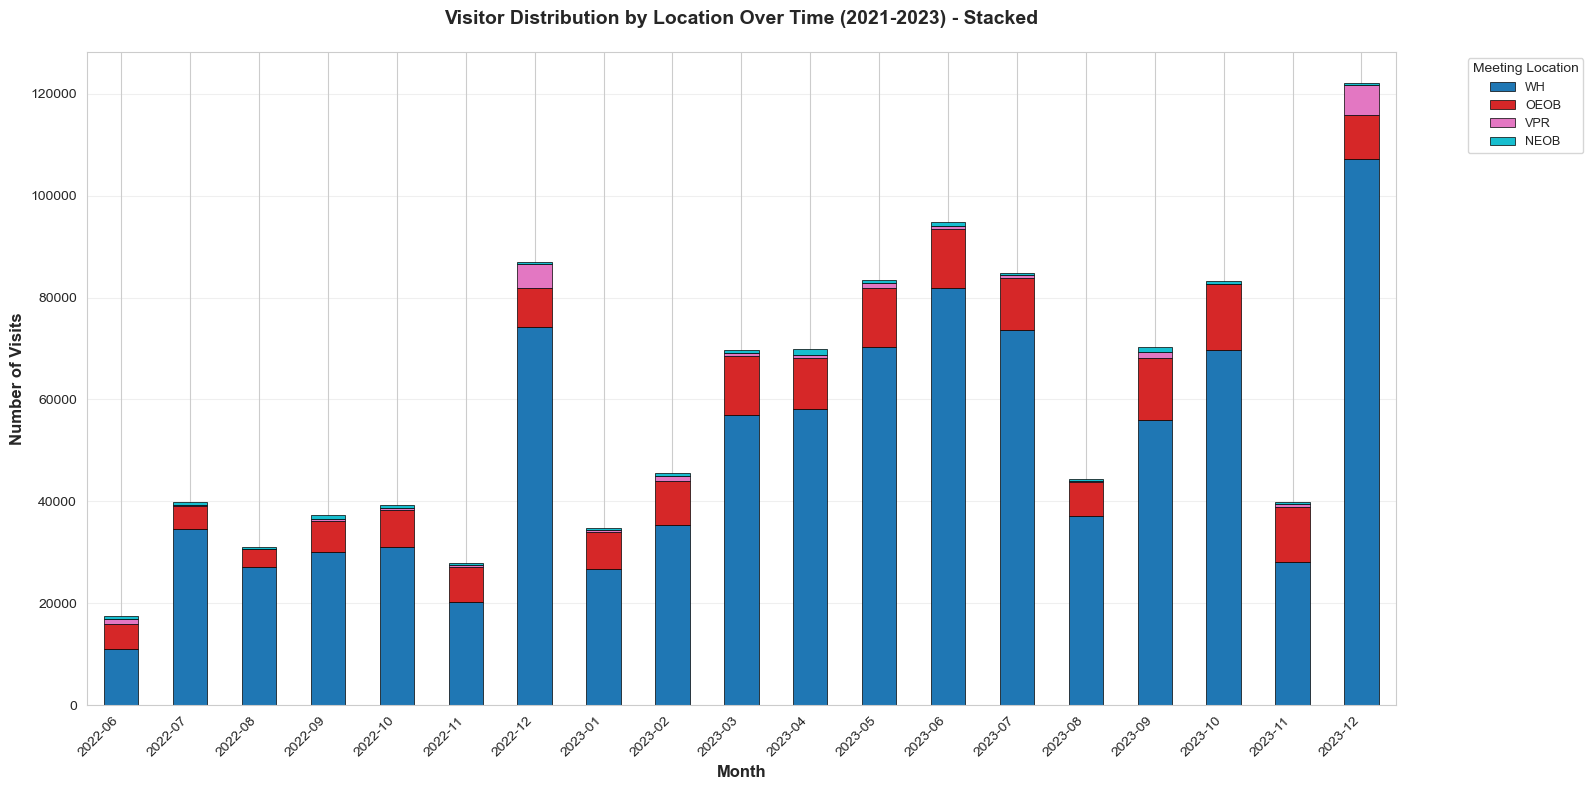

✓ Saved: 03_stacked_bar_chart_locations_time.png


In [134]:
print("Creating Stacked Bar Chart: Locations Over Time...")

# Ensure combined_df has the required columns
if 'year_month' not in combined_df.columns or 'Meeting Location' not in combined_df.columns:
    print("Error: Required columns not found in DataFrame")
else:
    # Check if there's data to plot
    if combined_df.empty:
        print("Error: DataFrame is empty")
    else:
        # Convert to numeric if needed and check data
        try:
            # Prepare data for stacking
            location_time = combined_df.groupby(['year_month', 'Meeting Location']).size().unstack(fill_value=0)
            
            # Check if we have data after grouping
            if location_time.empty:
                print("No data after grouping. Check your groupby columns.")
            else:
                # Select top 5 locations only if there are at least some locations
                if not location_time.columns.empty:
                    location_time = location_time[location_time.sum().sort_values(ascending=False).head(5).index]
                
                fig, ax = plt.subplots(figsize=(16, 8))
                location_time_sorted = location_time.sort_index()
                location_time_sorted.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', 
                                         edgecolor='black', linewidth=0.5)
                
                ax.set_xlabel('Month', fontsize=12, fontweight='bold')
                ax.set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
                ax.set_title('Visitor Distribution by Location Over Time (2021-2023) - Stacked', 
                            fontsize=14, fontweight='bold', pad=20)
                ax.legend(title='Meeting Location', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
                ax.set_xticklabels([label.get_text() for label in ax.get_xticklabels()], rotation=45, ha='right')
                ax.grid(axis='y', alpha=0.3)
                
                plt.tight_layout()
                plt.savefig('visualizations/03_stacked_bar_chart_locations_time.png', dpi=300, bbox_inches='tight')
                plt.show()
                print("✓ Saved: 03_stacked_bar_chart_locations_time.png")
        except Exception as e:
            print(f"Error during plotting: {e}")
            print("Try printing location_time.info() to debug data types")

## Chart 2: Column Chart - Top Visitees (Horizontal)

Creating Column Chart: Top Visitees...


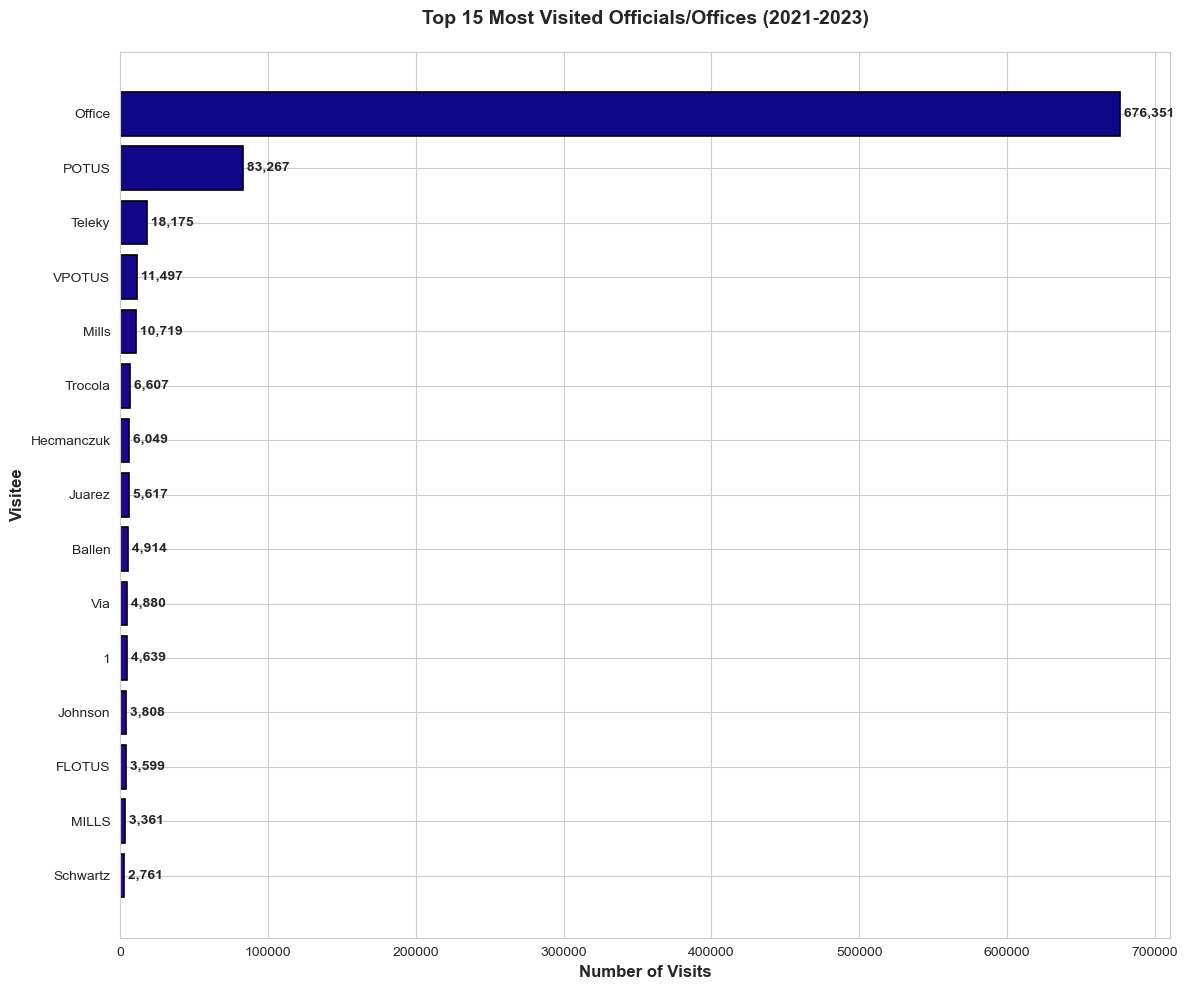

✓ Saved: 02_column_chart_top_visitees.png


In [135]:
print("Creating Column Chart: Top Visitees...")

fig, ax = plt.subplots(figsize=(12, 10))
visitee_counts = combined_df['Visitee Last Name'].value_counts().head(15)
colors = plt.cm.plasma(range(len(visitee_counts)))
bars = ax.barh(range(len(visitee_counts)), visitee_counts.values, color=colors, edgecolor='black', linewidth=1.2)

ax.set_ylabel('Visitee', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Visits', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Most Visited Officials/Offices (2021-2023)', fontsize=14, fontweight='bold', pad=20)
ax.set_yticks(range(len(visitee_counts)))
ax.set_yticklabels(visitee_counts.index)
ax.invert_yaxis()

# Add value labels
for i, (bar, value) in enumerate(zip(bars, visitee_counts.values)):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {value:,}',
            ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/02_column_chart_top_visitees.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 02_column_chart_top_visitees.png")

## Chart 4: Stacked Bar Chart (100%) - Location Proportions

Creating Stacked Bar Chart (100%): Location Proportions...


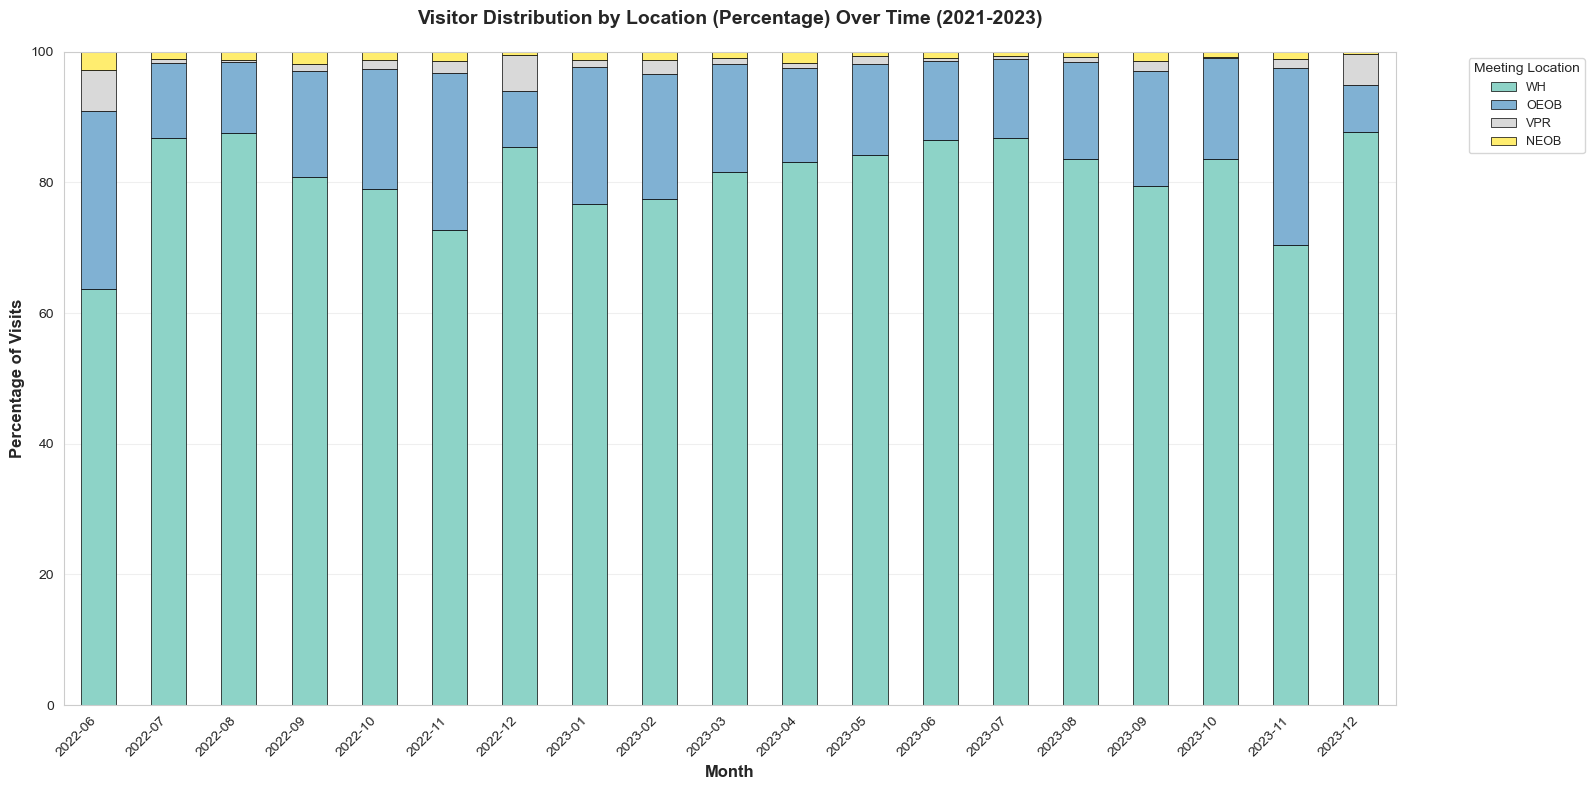

✓ Saved: 04_stacked_bar_chart_percentage.png


In [136]:
print("Creating Stacked Bar Chart (100%): Location Proportions...")

fig, ax = plt.subplots(figsize=(16, 8))
location_time_pct = location_time_sorted.div(location_time_sorted.sum(axis=1), axis=0) * 100
location_time_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Visits', fontsize=12, fontweight='bold')
ax.set_title('Visitor Distribution by Location (Percentage) Over Time (2021-2023)', fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Meeting Location', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_xticklabels([label.get_text() for label in ax.get_xticklabels()], rotation=45, ha='right')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/04_stacked_bar_chart_percentage.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 04_stacked_bar_chart_percentage.png")

## Chart 5: Line Chart - Monthly Visitor Trends

Creating Line Chart: Monthly Visitor Trends...


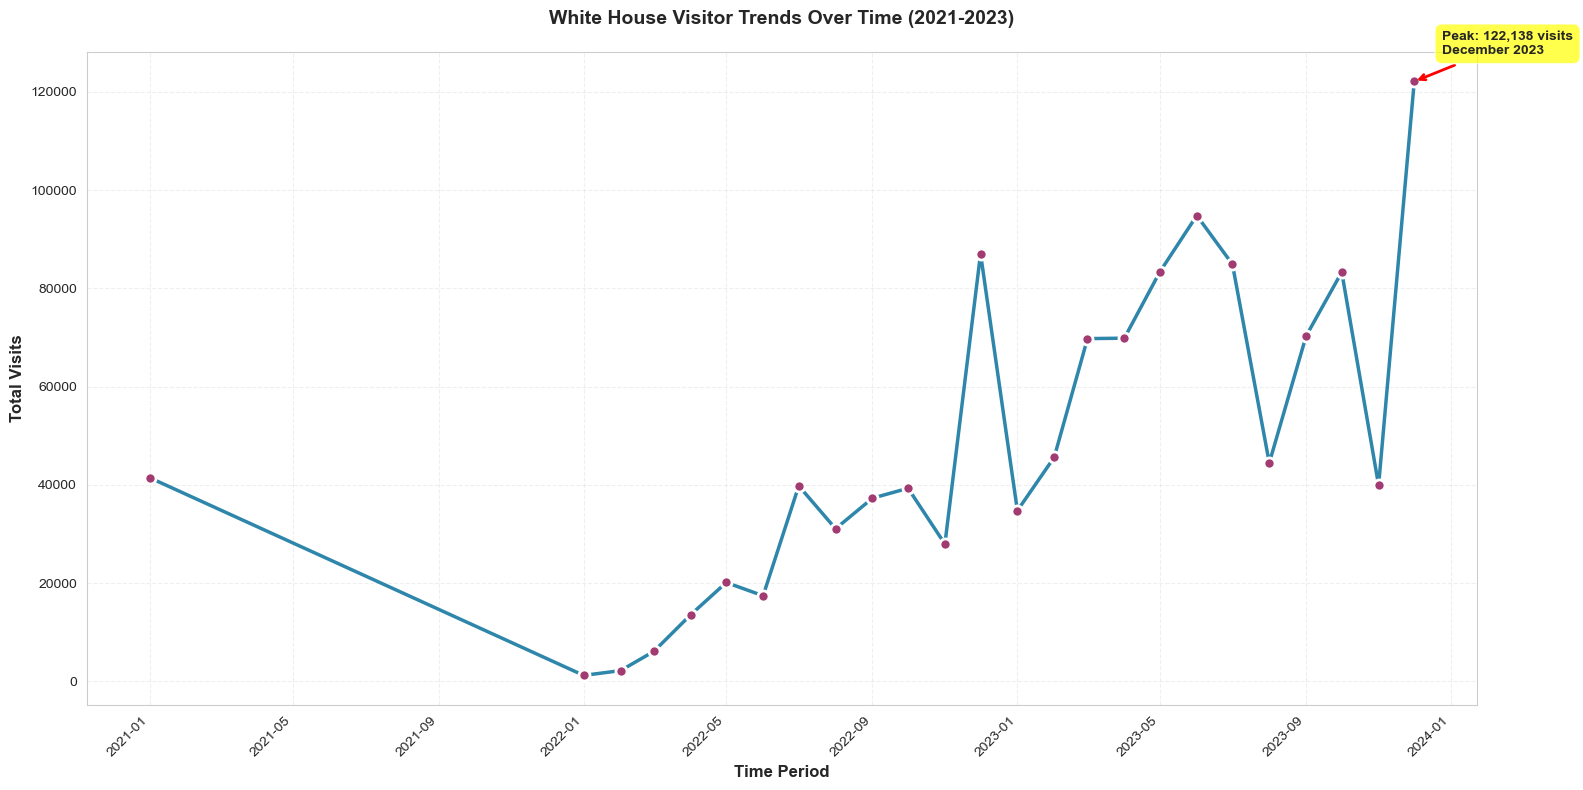

✓ Saved: 05_line_chart_monthly_trends.png


In [137]:
print("Creating Line Chart: Monthly Visitor Trends...")

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(monthly_visits['period'], monthly_visits['total_visits'], 
        marker='o', linewidth=2.5, markersize=8, color='#2E86AB', 
        markerfacecolor='#A23B72', markeredgewidth=2, markeredgecolor='white')

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Visits', fontsize=12, fontweight='bold')
ax.set_title('White House Visitor Trends Over Time (2021-2023)', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')

# Add annotations for peak months
peak_idx = monthly_visits['total_visits'].idxmax()
peak_value = monthly_visits.loc[peak_idx, 'total_visits']
peak_date = monthly_visits.loc[peak_idx, 'period']
ax.annotate(f'Peak: {peak_value:,} visits\n{peak_date.strftime("%B %Y")}',
            xy=(peak_date, peak_value),
            xytext=(20, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='red', lw=2),
            fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visualizations/05_line_chart_monthly_trends.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 05_line_chart_monthly_trends.png")

## Chart 6: Multi-Line Chart - Top Visitees Over Time

Creating Multi-Line Chart: Top Visitees Over Time...


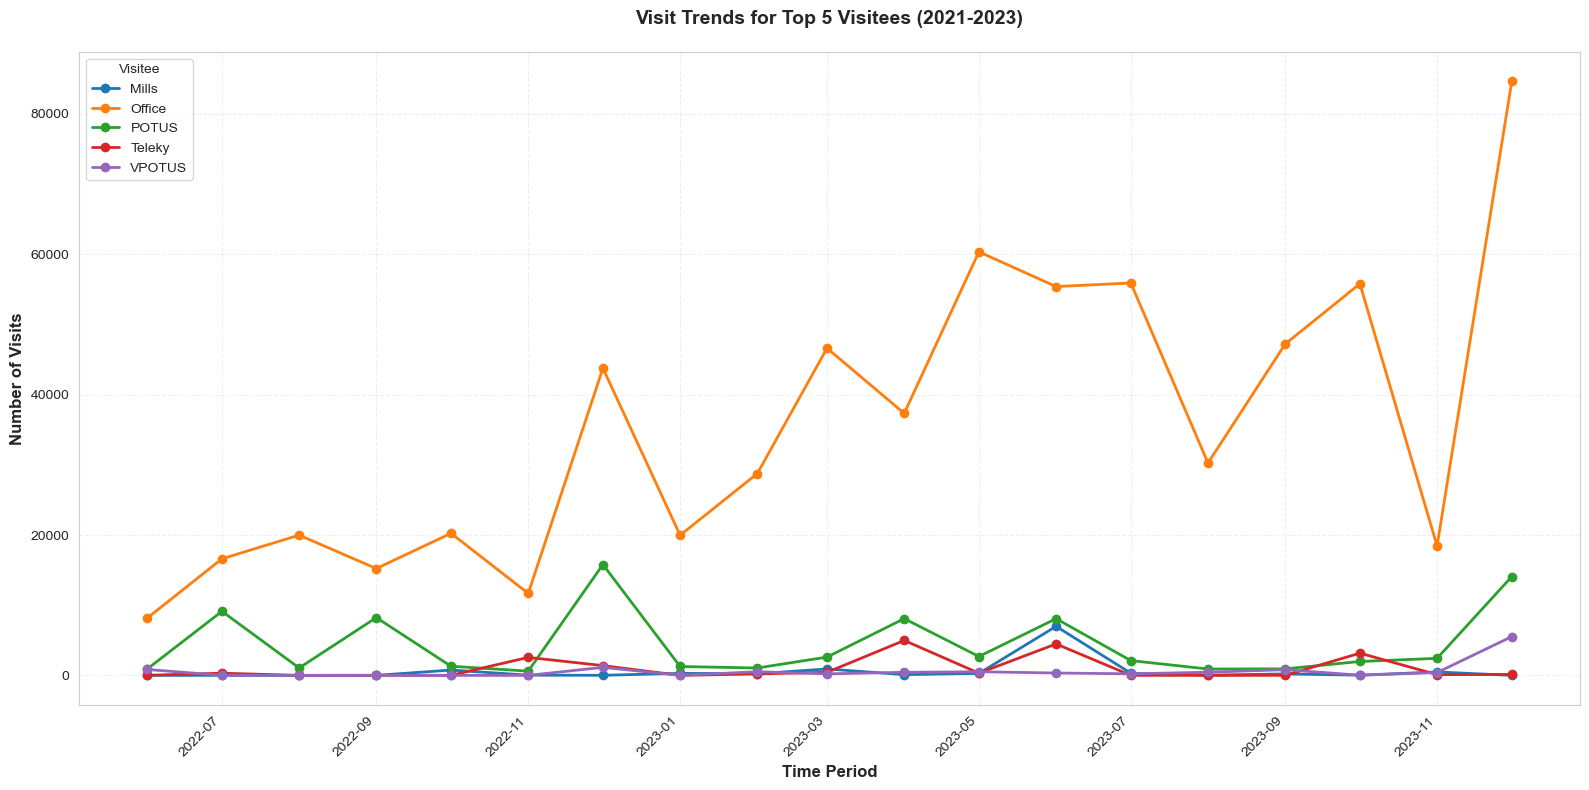

✓ Saved: 06_multiline_chart_visitee_trends.png


In [138]:
print("Creating Multi-Line Chart: Top Visitees Over Time...")

# Get top 5 visitees
top_visitees = combined_df['Visitee Last Name'].value_counts().head(5).index
visitee_time = combined_df[combined_df['Visitee Last Name'].isin(top_visitees)]
visitee_trends = visitee_time.groupby(['year_month', 'Visitee Last Name']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 8))
for column in visitee_trends.columns:
    dates = pd.to_datetime(visitee_trends.index, format='%Y-%m')
    ax.plot(dates, visitee_trends[column], marker='o', linewidth=2, markersize=6, label=column)

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Visits', fontsize=12, fontweight='bold')
ax.set_title('Visit Trends for Top 5 Visitees (2021-2023)', fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Visitee', loc='best', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visualizations/06_multiline_chart_visitee_trends.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 06_multiline_chart_visitee_trends.png")

## Chart 7: Step Chart - Monthly Visit Volume

Creating Step Chart: Monthly Visit Volume...


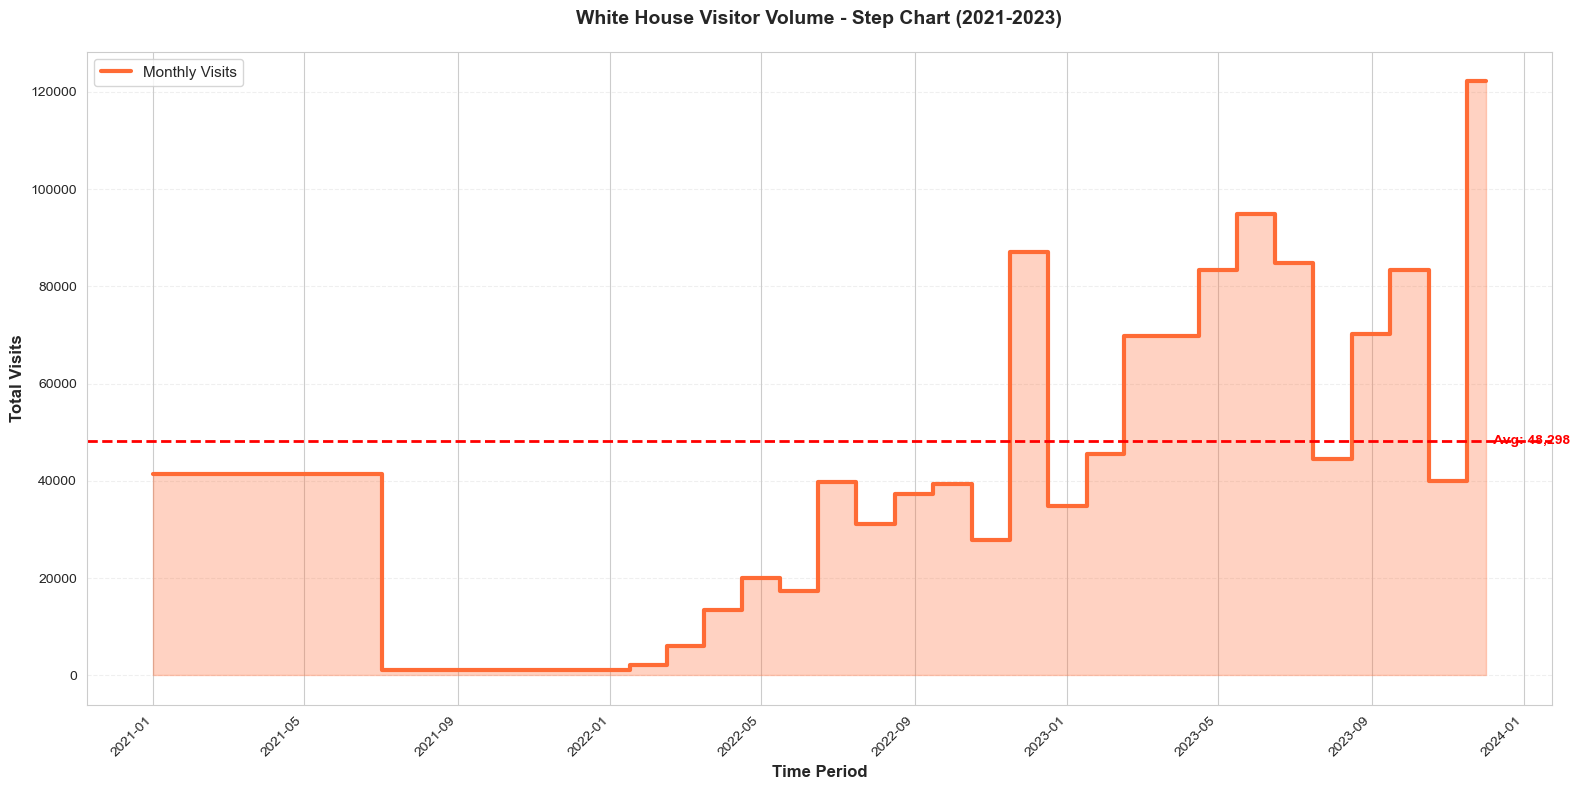

✓ Saved: 07_step_chart_monthly_volume.png


In [139]:
print("Creating Step Chart: Monthly Visit Volume...")

fig, ax = plt.subplots(figsize=(16, 8))
ax.step(monthly_visits['period'], monthly_visits['total_visits'], 
        where='mid', linewidth=3, color='#FF6B35', label='Monthly Visits')
ax.fill_between(monthly_visits['period'], monthly_visits['total_visits'], 
                step='mid', alpha=0.3, color='#FF6B35')

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Visits', fontsize=12, fontweight='bold')
ax.set_title('White House Visitor Volume - Step Chart (2021-2023)', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.legend(fontsize=11)

# Add horizontal mean line
mean_visits = monthly_visits['total_visits'].mean()
ax.axhline(y=mean_visits, color='red', linestyle='--', linewidth=2, label=f'Average: {mean_visits:,.0f}')
ax.text(monthly_visits['period'].iloc[-1], mean_visits, f'  Avg: {mean_visits:,.0f}', 
        va='center', fontsize=10, fontweight='bold', color='red')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visualizations/07_step_chart_monthly_volume.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 07_step_chart_monthly_volume.png")

## Chart 8: Scatter Plot - Visit Patterns Over Time (Multi-dimensional)

Creating Scatter Plot: Visit Patterns Over Time...


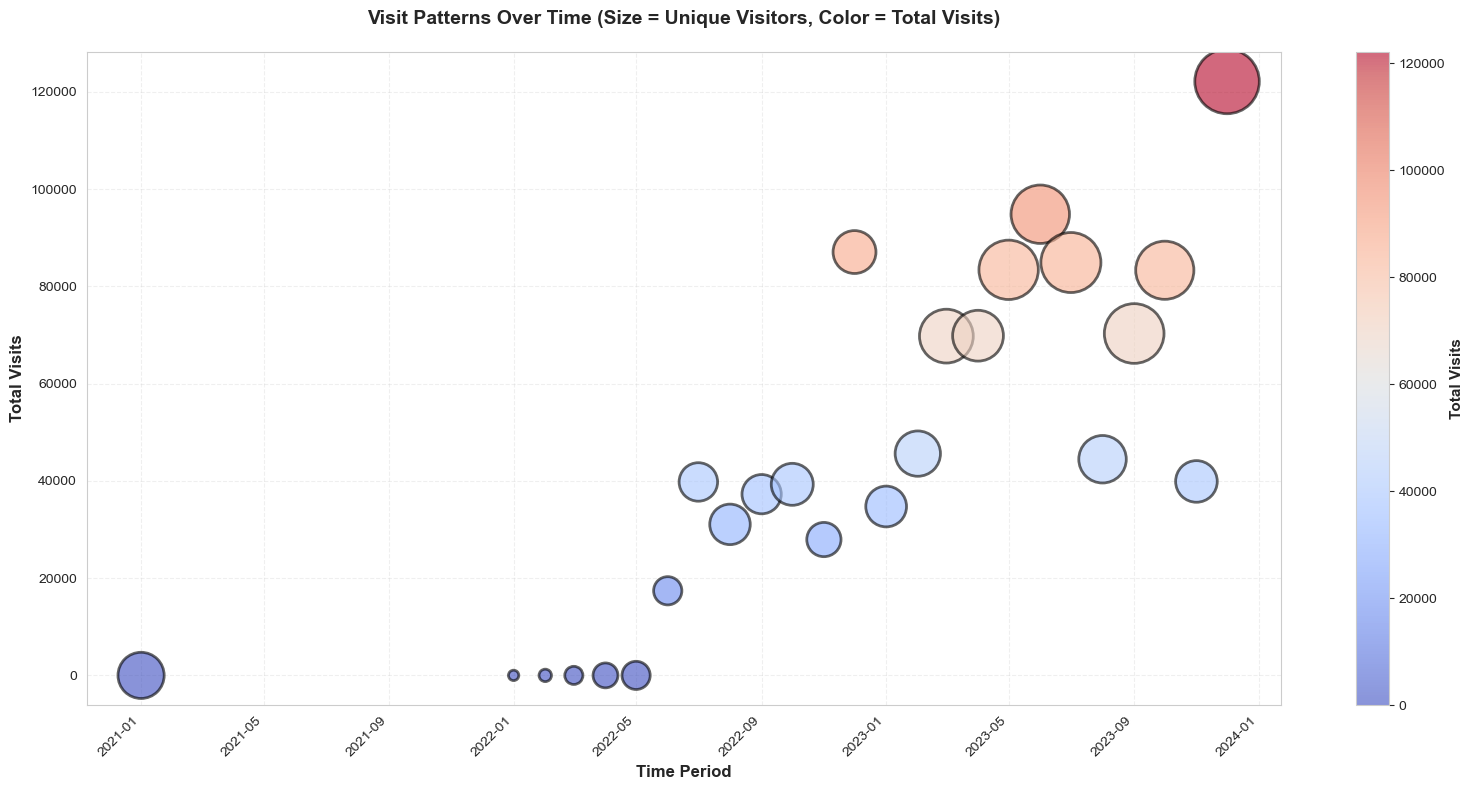

✓ Saved: 08_scatter_plot_time_patterns.png


In [140]:
print("Creating Scatter Plot: Visit Patterns Over Time...")

# Create data with unique visitors per month
monthly_stats = combined_df.groupby('year_month').agg({
    'UIN': 'nunique',
    'Meeting Location': 'count'
}).reset_index()
monthly_stats.columns = ['year_month', 'unique_visitors', 'total_visits']
monthly_stats['period'] = pd.to_datetime(monthly_stats['year_month'], format='%Y-%m', errors='coerce')
monthly_stats = monthly_stats.dropna(subset=['period'])

fig, ax = plt.subplots(figsize=(16, 8))
scatter = ax.scatter(monthly_stats['period'], monthly_stats['total_visits'],
                    s=monthly_stats['unique_visitors']/10,
                    c=monthly_stats['total_visits'], cmap='coolwarm',
                    alpha=0.6, edgecolors='black', linewidth=2)

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Visits', fontsize=12, fontweight='bold')
ax.set_title('Visit Patterns Over Time (Size = Unique Visitors, Color = Total Visits)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Visits', fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visualizations/08_scatter_plot_time_patterns.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 08_scatter_plot_time_patterns.png")

## Chart 9: Scatter Plot - Total vs Unique Visitors (with Trend Line)

Creating Scatter Plot: Total vs Unique Visitors...


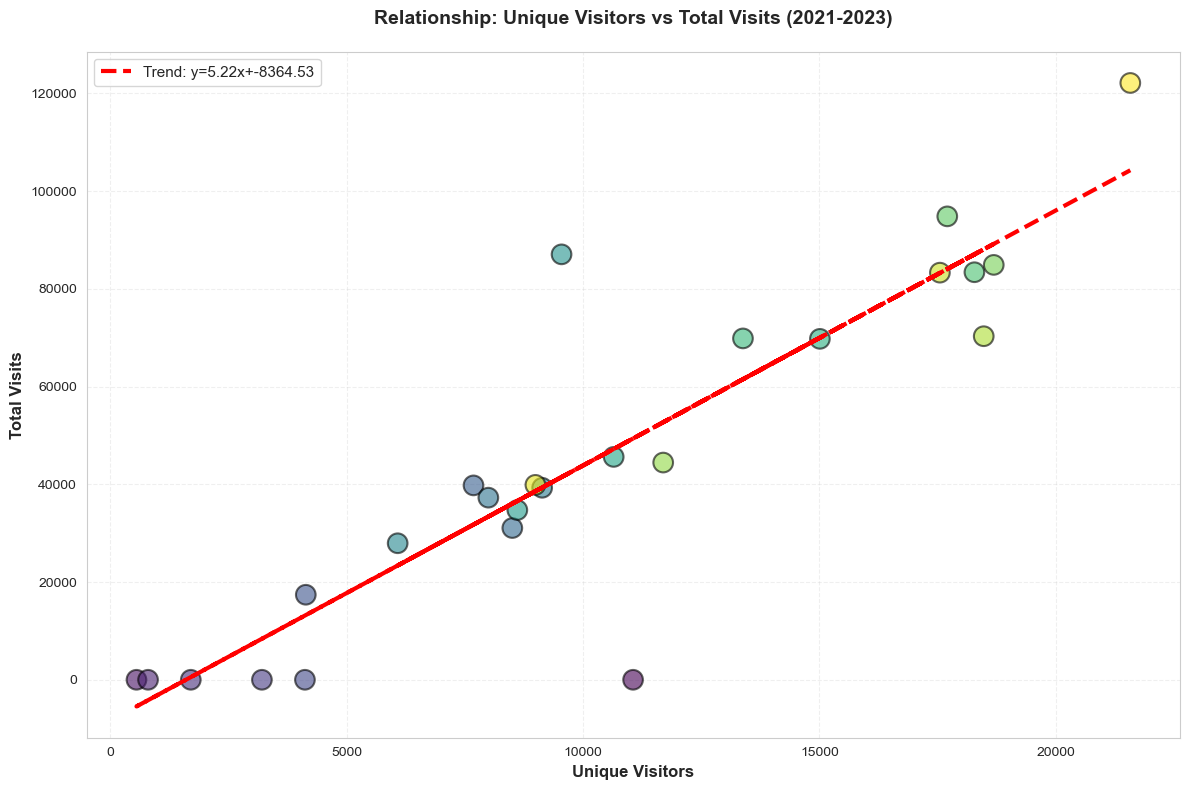

✓ Saved: 09_scatter_plot_unique_vs_total.png


In [141]:
print("Creating Scatter Plot: Total vs Unique Visitors...")

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(monthly_stats['unique_visitors'], monthly_stats['total_visits'],
          s=200, alpha=0.6, c=range(len(monthly_stats)), cmap='viridis',
          edgecolors='black', linewidth=1.5)

# Add trend line
z = np.polyfit(monthly_stats['unique_visitors'], monthly_stats['total_visits'], 1)
p = np.poly1d(z)
ax.plot(monthly_stats['unique_visitors'], p(monthly_stats['unique_visitors']),
        "r--", linewidth=3, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')

ax.set_xlabel('Unique Visitors', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Visits', fontsize=12, fontweight='bold')
ax.set_title('Relationship: Unique Visitors vs Total Visits (2021-2023)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('visualizations/09_scatter_plot_unique_vs_total.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 09_scatter_plot_unique_vs_total.png")

## Chart 10: Step Chart - Cumulative Visitors

Creating Step Chart: Cumulative Visitors...


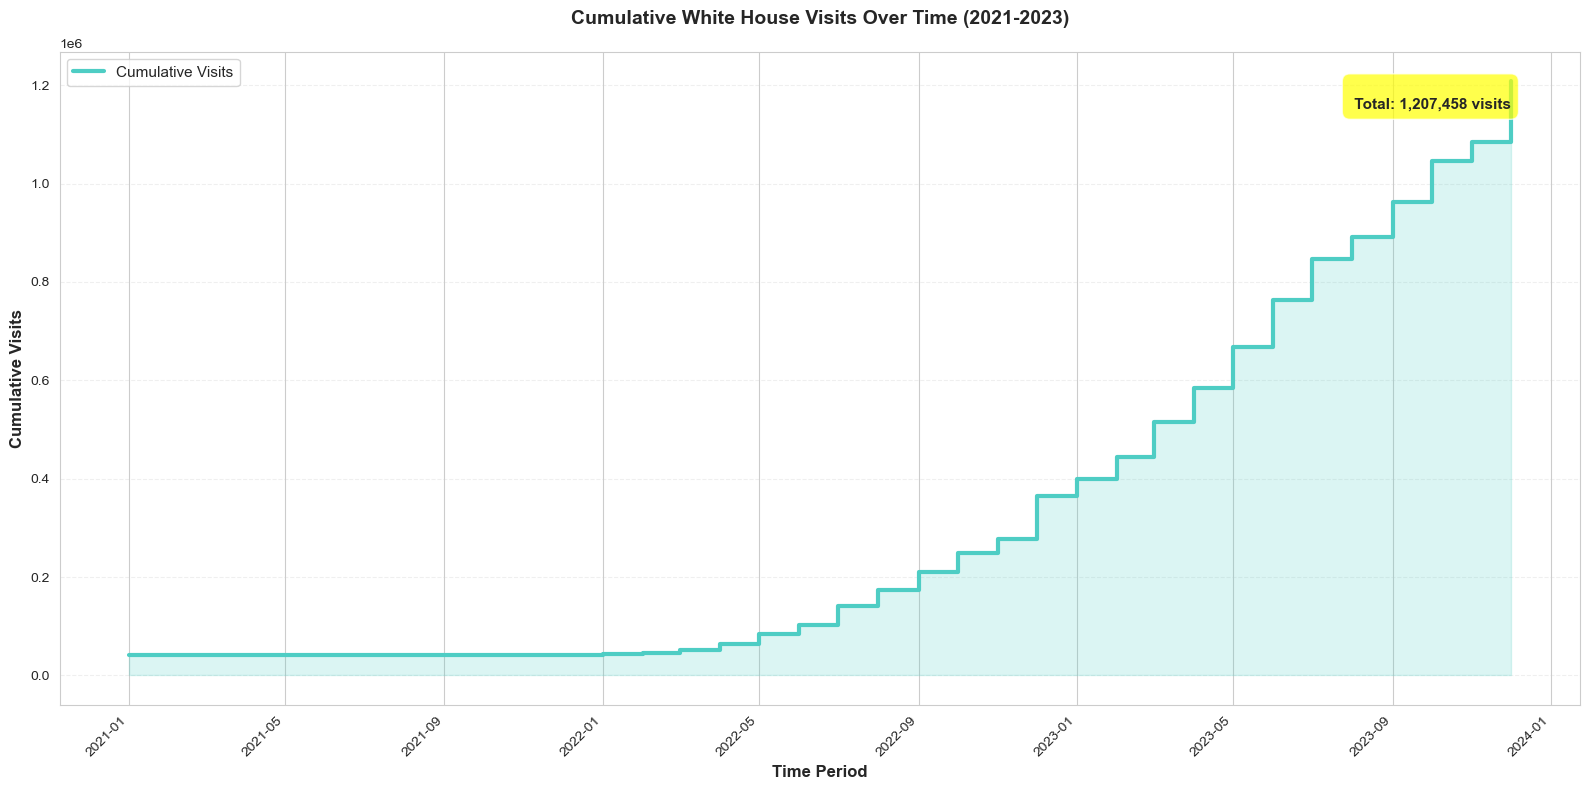

✓ Saved: 10_step_chart_cumulative.png


In [142]:
print("Creating Step Chart: Cumulative Visitors...")

monthly_visits_sorted = monthly_visits.sort_values('period')
monthly_visits_sorted['cumulative_visits'] = monthly_visits_sorted['total_visits'].cumsum()

fig, ax = plt.subplots(figsize=(16, 8))
ax.step(monthly_visits_sorted['period'], monthly_visits_sorted['cumulative_visits'],
        where='post', linewidth=3, color='#4ECDC4', label='Cumulative Visits')
ax.fill_between(monthly_visits_sorted['period'], monthly_visits_sorted['cumulative_visits'],
                step='post', alpha=0.2, color='#4ECDC4')

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Visits', fontsize=12, fontweight='bold')
ax.set_title('Cumulative White House Visits Over Time (2021-2023)', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.legend(fontsize=11, loc='upper left')

# Add milestone annotations
total = monthly_visits_sorted['cumulative_visits'].iloc[-1]
ax.text(monthly_visits_sorted['period'].iloc[-1], total,
        f'\n Total: {total:,} visits',
        ha='right', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visualizations/10_step_chart_cumulative.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 10_step_chart_cumulative.png")

## Chart 11: Combined Line + Scatter Chart

Creating Combined Chart: Line + Scatter Overlay...


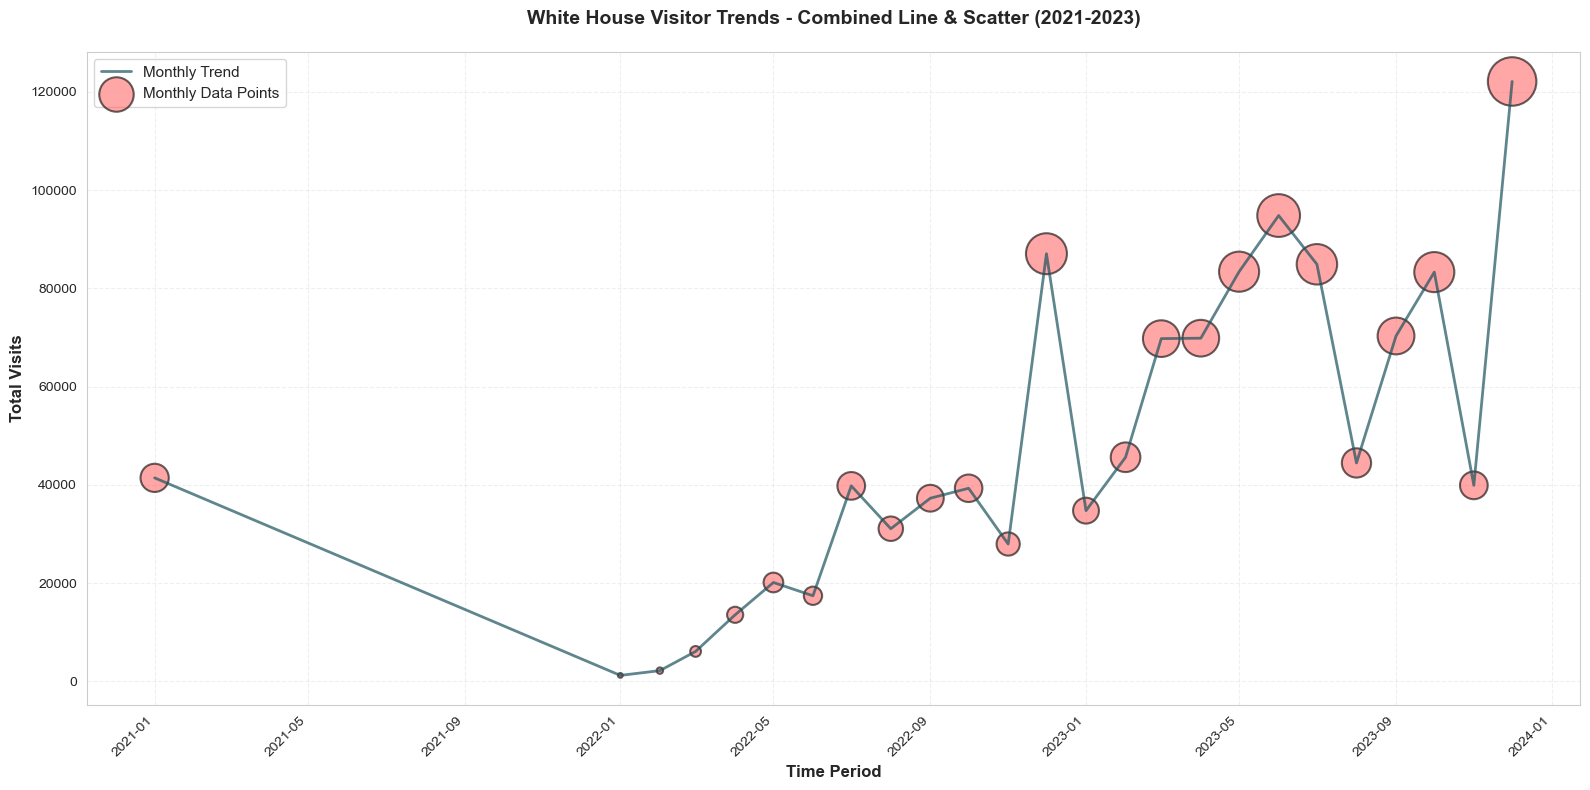

✓ Saved: 11_combined_line_scatter.png


In [143]:
print("Creating Combined Chart: Line + Scatter Overlay...")

fig, ax = plt.subplots(figsize=(16, 8))

# Line plot
ax.plot(monthly_visits['period'], monthly_visits['total_visits'],
        linewidth=2, color='#1A535C', alpha=0.7, label='Monthly Trend')

# Scatter overlay
ax.scatter(monthly_visits['period'], monthly_visits['total_visits'],
          s=monthly_visits['total_visits']/100, c='#FF6B6B',
          alpha=0.6, edgecolors='black', linewidth=1.5, label='Monthly Data Points')

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Visits', fontsize=12, fontweight='bold')
ax.set_title('White House Visitor Trends - Combined Line & Scatter (2021-2023)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='best')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visualizations/11_combined_line_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 11_combined_line_scatter.png")

---

## Summary and Completion

In [144]:
print("\n" + "="*60)
print("VISUALIZATION COMPLETE!")
print("="*60)
print(f"✓ Generated 11 different chart types")
print(f"✓ All visualizations saved in: ./visualizations/")
print("\nChart Types Created:")
print("  1. Bar Chart - Top Meeting Locations")
print("  2. Column Chart (Horizontal) - Top Visitees")
print("  3. Stacked Bar Chart - Locations Over Time")
print("  4. Stacked Bar Chart (100%) - Location Proportions")
print("  5. Line Chart - Monthly Visitor Trends")
print("  6. Multi-Line Chart - Top Visitees Over Time")
print("  7. Step Chart - Monthly Visit Volume")
print("  8. Scatter Plot - Visit Patterns (with size/color encoding)")
print("  9. Scatter Plot - Unique vs Total Visitors (with trend line)")
print(" 10. Step Chart - Cumulative Visitors")
print(" 11. Combined Line + Scatter Chart")
print("="*60)

# List generated files
viz_files = sorted(os.listdir('visualizations'))
print(f"\nGenerated Files ({len(viz_files)}):")
for file in viz_files:
    size_kb = os.path.getsize(f'visualizations/{file}') / 1024
    print(f"  - {file} ({size_kb:.1f} KB)")


VISUALIZATION COMPLETE!
✓ Generated 11 different chart types
✓ All visualizations saved in: ./visualizations/

Chart Types Created:
  1. Bar Chart - Top Meeting Locations
  2. Column Chart (Horizontal) - Top Visitees
  3. Stacked Bar Chart - Locations Over Time
  4. Stacked Bar Chart (100%) - Location Proportions
  5. Line Chart - Monthly Visitor Trends
  6. Multi-Line Chart - Top Visitees Over Time
  7. Step Chart - Monthly Visit Volume
  8. Scatter Plot - Visit Patterns (with size/color encoding)
  9. Scatter Plot - Unique vs Total Visitors (with trend line)
 10. Step Chart - Cumulative Visitors
 11. Combined Line + Scatter Chart

Generated Files (12):
  - .ipynb_checkpoints (0.2 KB)
  - 01_bar_chart_meeting_locations.png (146.7 KB)
  - 02_column_chart_top_visitees.png (205.6 KB)
  - 03_stacked_bar_chart_locations_time.png (186.1 KB)
  - 04_stacked_bar_chart_percentage.png (173.8 KB)
  - 05_line_chart_monthly_trends.png (321.3 KB)
  - 06_multiline_chart_visitee_trends.png (410.1 KB)

---

## Next Steps

### Recommended Analyses
1. **Time-of-day patterns** - If TOA (Time of Arrival) data is more complete
2. **Day-of-week analysis** - Extract weekday patterns from appointment dates
3. **Badge number trends** - Analyze repeat vs. one-time visitors
4. **Seasonal patterns** - Deeper dive into monthly variations

### Export Options
- All charts are saved as 300 DPI PNG files in `./visualizations/`
- Combined dataset available as `WAVES_Combined_2021-2023.csv`
- Ready for presentations, reports, or further analysis

### Documentation
- See `White_House_Visitor_Records_Ethics_Analysis.md` for ethical considerations
- See `VISUALIZATION_GUIDE.md` for detailed chart descriptions

---

**Analysis Complete!** 🎉